# Future Risk

Here we run a calculation for future risk, looking at how growth and climate change affect future modelled impacts.

In this notebook we will

- Create a future Entity object, where future assets are created from present-day assets, with scaled values according to projected growth.
- Create a future Hazard object, where we adjust the frequencies of present-day events to reflect future changes in climate risk
- Create a waterfall plot breaking down future changes in risk into growth and climate change.

Here we examine the Residential risk.

In [1]:
# -------------------------------
# Specify parameters for the analysis
# -------------------------------

YEAR_PRESENT = 2025
YEAR_FUTURE = 2050

In [2]:
from pathlib import Path

# -------------------------------
# Set up paths to data
# -------------------------------

# Entity files
ENTITY_DIR = "../data/entity_files_calibrated/"
ENTITY_FILE = "ICA_PERU_Entity_Floods_Residential_calibrated.xlsx"
entity_filepath = Path(ENTITY_DIR) / ENTITY_FILE

# Hazard .tif layers
HAZARD_DIR = "../data/hazard/"
HAZARD_FILES = ["tr10_h_max_61200_4326.tif", "tr25_h_max_61200_4326.tif", "tr50_h_max_61200_4326.tif", "tr100_h_max_61200_4326.tif", "tr200_h_max_61200_4326.tif", "tr500_h_max_72000_4326.tif"]
haz_filepaths = [Path(HAZARD_DIR) / filename for filename in HAZARD_FILES]

# Socioeconomic growth projections
GROWTH_RATES_FILEPATH = "../data/socioeconomic_change/growth_projections.csv"
# Projected future changes in hazard return periods
RP_MAPPING_FILEPATH = "../data/hazard/ica_rp_mapping_2025_2050.csv"


## Create present-day and future Entity objects

### Read in present-day Entity file

In [3]:
import copy
from climada.entity import Entity

# Read the Entity file and set additional metadata for the Exposures
print(f"Reading {entity_filepath}...")
entity_present = Entity.from_excel(entity_filepath)
entity_present.exposures.ref_year = YEAR_PRESENT
entity_present.exposures.value_unit = "USD"
entity_present.exposures.description = f"Residential Exposures (Present, {YEAR_PRESENT})"

Reading ../data/entity_files_calibrated/ICA_PERU_Entity_Floods_Residential_calibrated.xlsx...


### Apply projected growth to Exposures

There are two ways to create a future Entity object: directly in an Excel file, or by making adjustments in code. In general only the Exposures change between present-day and future Entity objects: everything else (impact functions, discount rates, measures) should remain the same. Otherwise you may get unexpected behavior.

In this analysis, our future assets are created by scaling present-day asset values. Their geographic location remains the same. This is most easily done in code (and saves us from updating two versions of the Entity file when we make changes to other sheets in the file).


In [4]:
import pandas as pd

# Load growth rate data
growth_rates_df = pd.read_csv(GROWTH_RATES_FILEPATH).set_index("Year")

# Filter to years between present and future
growth_rates_df = growth_rates_df.loc[(growth_rates_df.index > YEAR_PRESENT) & (growth_rates_df.index <= YEAR_FUTURE)]
display(growth_rates_df)


,Population Growth Estimates,GDP Growth Rate
Year,,
2026,0.010,0.025
2027,0.009,0.028
2028,0.009,0.027
2029,0.009,0.027
2030,0.008,0.028
2031,0.008,0.030
2032,0.008,0.033
2033,0.007,0.035
2034,0.007,0.035


In [5]:
import numpy as np

# Calculate the total growth over the whole study period
growth_factor_population = np.prod(1 + growth_rates_df["Population Growth Estimates"].values)
growth_factor_gdp = np.prod(1 + growth_rates_df["GDP Growth Rate"].values)
print(f"Population increase from present: {(growth_factor_population - 1) * 100:.2f}%")
print(f"GDP increase from present: {(growth_factor_gdp - 1) * 100:.2f}%")

Population increase from present: 16.94%
GDP increase from present: 100.57%


In [6]:
# -------------------------------
# Create the future Entity
# -------------------------------

# Copy the present-day Entity
entity_future = copy.deepcopy(entity_present)

# Apply the GDP growth factor to the exposure values
entity_future.exposures.gdf["value"] = entity_future.exposures.gdf["value"] * growth_factor_gdp

# Update the reference year for the future Entity
entity_future.exposures.ref_year = YEAR_FUTURE
entity_future.exposures.description = f"Residential Exposures (Future, {YEAR_FUTURE})"

print("Future exposure created")
print(f"GDP increase %: {(growth_factor_gdp - 1) * 100:.2f}%")
print(f"Present-day exposure value: {entity_present.exposures.gdf['value'].sum():,.0f} USD")
print(f"Future exposure value: {entity_future.exposures.gdf['value'].sum():,.0f} USD")


Future exposure created
GDP increase %: 100.57%
Present-day exposure value: 7,863,601,676 USD
Future exposure value: 15,771,704,157 USD


<GeoAxes: title={'center': 'Residential Exposures (Future, 2050)'}>

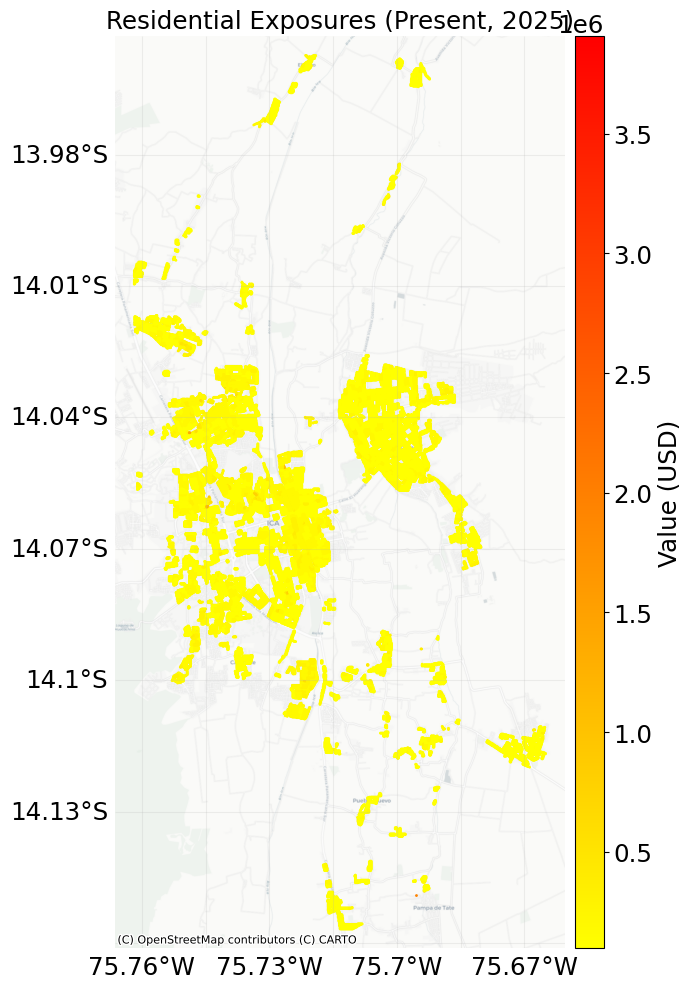

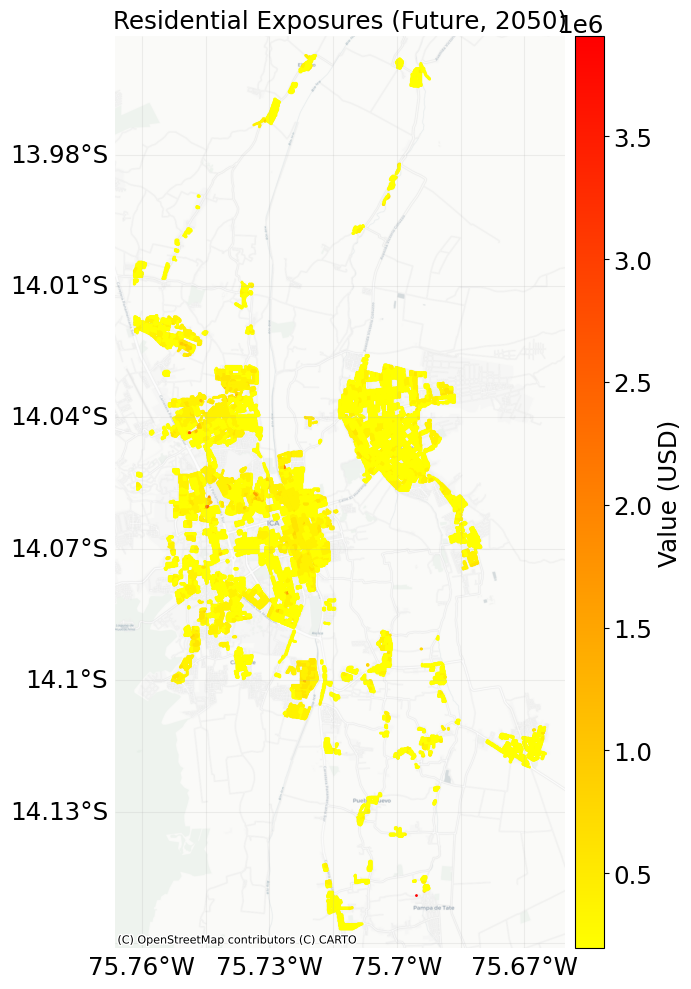

In [7]:
# -------------------------------
# Plot the Exposures
# -------------------------------

max_value = entity_future.exposures.gdf["value"].max()
entity_present.exposures.plot_basemap(
        title=entity_present.exposures.description,
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=14,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=max_value,          # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)
)
entity_future.exposures.plot_basemap(
        title=entity_future.exposures.description,
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=14,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=max_value,          # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)
)

## Create present-day and future Hazard objects

### Read present-day hazard data

In [8]:
from climada.hazard import Hazard

# Since we're reading hazard data from .tif files, we need to provide some additional metadata, including a frequency for each event
# As shown in the Hazard notebook, we have to convert return period frequencies to event frequencies:
RETURN_PERIODS_PRESENT = [10, 25, 50, 100, 200, 500]

def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]  # Reverse the list so that it's in order of increasing frequency (decreasing return period)
    exceedance_frequency = np.array([1/rp for rp in rp_rev])
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency]))
    event_frequency = event_frequency[::-1]  # Reverse the frequencies so that they match the order of the events in the hazard file again
    return event_frequency

event_frequency = event_frequency_from_return_periods(RETURN_PERIODS_PRESENT)


# Read in the hazard data
haz_present = Hazard.from_raster(
    files_intensity = haz_filepaths,
    attrs={
        'unit': 'm',
        'event_name': [f'Return period {rp}' for rp in RETURN_PERIODS_PRESENT],     # We can optionally name the events
        'frequency': event_frequency                                         # For probabilistic analyses we have to define the frequency of each event
    },
    haz_type='FL'
)

2026-07-02 15:06:58,431 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-07-02 15:07:04,625 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-07-02 15:07:04,814 - climada.util.coordinates - INFO - Reading ../data/hazard/tr25_h_max_61200_4326.tif
2026-07-02 15:07:05,011 - climada.util.coordinates - INFO - Reading ../data/hazard/tr50_h_max_61200_4326.tif
2026-07-02 15:07:05,202 - climada.util.coordinates - INFO - Reading ../data/hazard/tr100_h_max_61200_4326.tif
2026-07-02 15:07:05,484 - climada.util.coordinates - INFO - Reading ../data/hazard/tr200_h_max_61200_4326.tif
2026-07-02 15:07:05,681 - climada.util.coordinates - INFO - Reading ../data/hazard/tr500_h_max_72000_4326.tif


In [9]:
# Drop hazard centroids with zero hazard

# Unusually for a CLIMADA simulation, we want to remove locations with zero modelled hazard. This is because the flood simulation's very detailed DEM recognises the roofs of houses and doesn't model hazard at these locations.
# We solve this by removing centroids located within the housing polygons – and anywhere else that never experiences a hazard – we want rooftops to be _missing_ values rather than _zero_ values, forcing CLIMADA to use flood information from non-missing locations, i.e. the nearby streets.

intensity_threshold = 0.05       # 5 cm and less we'll ignore
ix = haz_present.intensity.max(axis=0) < intensity_threshold    # Use the hazard intensity matrix to identify centroids 
assert ix.sum() > 0     # Ensure this hasn't removed all cpoints
ix = ix.todense().A1    # Convert from sparse matrix to 1D array of booleans
# Remove any grid cells with zero intensity across all events
haz_present.centroids.gdf["region_id"] = ix.astype(int)   # (bit hacky) set the hazard's centroid region IDs to 0 (centroid affected) or 1 (centroid never affected)
haz_present = haz_present.select(reg_id=0)  # Subset the Hazard to only include grid cells with non-zero intensity across all events

/usr/local/Caskroom/miniforge/base/envs/climada_env/lib/python3.11/site-packages/scipy/sparse/_base.py:463: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  return self.tocsr().__lt__(other)


### Create future Hazard data

When you specify future hazard information, you can do this by reading in a different dataset (e.g. with the output of future simulations), or by making adjustments to the present-day hazard.

Since we don't have high-resolution future flood simulations for Ica from the model that produced our present-day hazard information, we will adjust the present-day hazard.

We do this by changing the Hazard object's frequency information, making each event more (or less) likely to happen in a given year in the future climate. (We don't recommend adjusting the hazard intensities: this is harder to estimate well and often results in unphysical flood footprints.)

Since we are working with return-period footprints, we will map present-day return periods to projected future return periods, and recalculate the event frequencies after this mapping.

**Note:** here we apply a simple adjustment that roughly doubles the frequency of all flood events. We recommend using information from the literature on heavy precipitation or flood frequency changes in the region to produce better estimates.

In [10]:
# -------------------------------
# Read in return period mappings
# -------------------------------

rp_mapping_df = pd.read_csv(RP_MAPPING_FILEPATH)

assert np.array_equal(
        RETURN_PERIODS_PRESENT,
        rp_mapping_df["present_return_period"].values
    ), "RP mapping table must contain the same present-day return periods as the hazard files."

display(rp_mapping_df)


,present_depth_map,present_return_period,future_return_period_2050,interpretation,present_frequency,future_frequency_2050
0,HIST_RP_10,10,5,Present RP10 depth becomes future RP5,0.100,0.200
1,HIST_RP_20,25,10,Present RP20 depth becomes future RP10,0.050,0.100
2,HIST_RP_50,50,20,Present RP50 depth becomes future RP20,0.020,0.050
3,HIST_RP_100,100,50,Present RP100 depth becomes future RP50,0.010,0.020
4,HIST_RP_200,200,100,Present RP200 depth becomes future RP100,0.005,0.010
5,HIST_RP_500,500,200,Present RP500 depth becomes future RP200,0.002,0.005


In [11]:
# -------------------------------
# Create a future hazard by changing present-day return periods
# -------------------------------

return_periods_future = rp_mapping_df["future_return_period_2050"].values

haz_future = copy.deepcopy(haz_present)
haz_future.frequency = event_frequency_from_return_periods(return_periods_future)
haz_future.event_name = [f'Return period {rp}' for rp in return_periods_future]

print("Future shifted hazard created")
print("Present return periods:", RETURN_PERIODS_PRESENT)
print("Future return periods:", return_periods_future)
print("Present event frequencies:", haz_present.frequency)
print("Future event frequencies:", haz_future.frequency)

Future shifted hazard created
Present return periods: [10, 25, 50, 100, 200, 500]
Future return periods: [  5  10  20  50 100 200]
Present event frequencies: [0.06  0.02  0.01  0.005 0.003 0.002]
Future event frequencies: [0.1   0.05  0.03  0.01  0.005 0.005]


In [12]:
# ------------------------------------------
# Assign hazard centroids to the exposures
# ------------------------------------------

# See the 04_uncalibrated_risk.ipynb notebook for how we chose this threshold
# This must be done before any impact calculations, whether through ImpactCalc or CostBenefit
dist_threshold = 0.0002

entity_present.exposures.assign_centroids(haz_present, threshold=dist_threshold, overwrite=True)
entity_future.exposures.assign_centroids(haz_future, threshold=dist_threshold, overwrite=True)

2026-07-02 15:07:08,243 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-07-02 15:07:08,764 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-07-02 15:07:09,712 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.
2026-07-02 15:07:09,722 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-07-02 15:07:10,141 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-07-02 15:07:11,060 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.


## Show components of changing risk in a waterfall plot

One of the most useful visualizations for how modelled risk changes between present-day and future climates is the waterfall plot. It breaks down the change into change driven by growth, and change from climate change. In the calculation, that means change from the future Entity and change from the future Hazard objects.

The plot is generated from the `CostBenefit.plot_waterfall` method (but doesn't use Measures). We look at the other parts of a cost-benefit analysis in a later notebook.


2026-07-02 15:07:11,139 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
2026-07-02 15:07:11,194 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
2026-07-02 15:07:11,253 - climada.engine.cost_benefit - INFO - Risk at 2025: 5.597e+05
2026-07-02 15:07:11,267 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
2026-07-02 15:07:11,312 - climada.engine.cost_benefit - INFO - Risk with development at 2050: 1.123e+06
2026-07-02 15:07:11,312 - climada.engine.cost_benefit - INFO - Risk with development and climate change at 2050: 2.540e+06


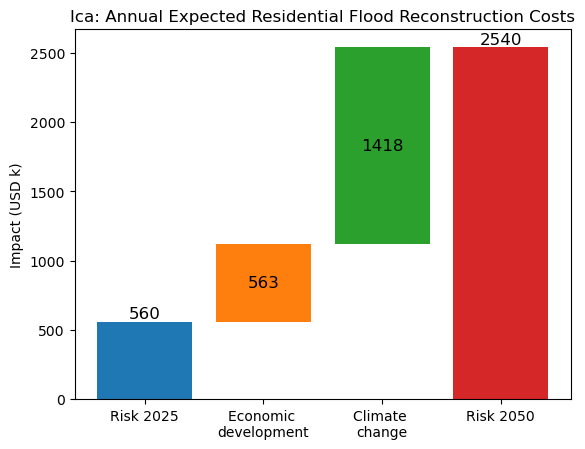

In [13]:
from climada.engine import CostBenefit

cb = CostBenefit()

ax = cb.plot_waterfall(
    haz_present,
    entity_present,
    haz_future,
    entity_future
)
ax = ax.set_title("Ica: Annual Expected Residential Flood Reconstruction Costs")

The three components of the average annual risk shown in the plot come from three Impact calculations run by CLIMADA:

- Baseline risk (present-day Hazard and present-day Entity)
- Economic development (calculating the difference from baseline to risk with present-day Hazard and future Entity)
- Economic development + climate change (calculating the difference from only economic change to risk with future Hazard and future Entity)

Note that the 'climate change' component is applied _on top of_ the economic growth.

In this plot we see that

- The risk roughly doubles due to growth. This makes sense, as we scaled our Exposures by roughly a factor of two to create the future Entity
- The risk more than doubles again due to climate change. Again, this makes sense since our adjustment to event frequencies roughly doubled them.

Later in this notebook we will create a more detailed version of the plot.

## Compare present-day and future risk

We can compare the changes in modelled risk by calculating the Impacts for present and future climates.

In [14]:
from climada.engine import ImpactCalc

# ------------------------------------------
# Run impact calculations for present and future scenarios
# ------------------------------------------

impact_present = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

impact_future = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

print(f"Present-day annual expected flood impact: {impact_present.aai_agg:,.0f} USD")
print(f"Future annual expected flood impact: {impact_future.aai_agg:,.0f} USD")

2026-07-02 15:07:11,468 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.
2026-07-02 15:07:11,526 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.
Present-day annual expected flood impact: 559,693 USD
Future annual expected flood impact: 2,540,387 USD


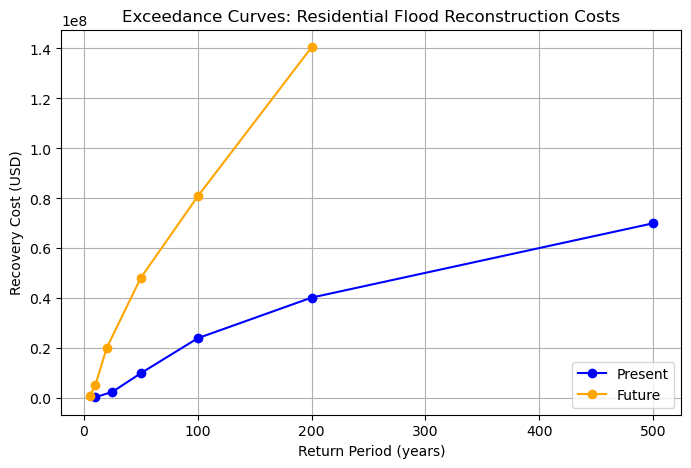

In [15]:
import matplotlib.pyplot as plt

# ---------------------------
# Compare Exceedance curves
# ---------------------------

exceedance_present = impact_present.calc_freq_curve()
exceedance_future = impact_future.calc_freq_curve()

fig, axis = plt.subplots(figsize=(8, 5))
exceedance_present.plot(axis=axis, color="blue", marker="o", label="Present")
exceedance_future.plot(axis=axis, color="orange", marker="o", label="Future")
axis.set_title("Exceedance Curves: Residential Flood Reconstruction Costs")
axis.set_xlabel("Return Period (years)")
axis.set_ylabel("Recovery Cost (USD)")
plt.grid(True)
axis.legend(loc="lower right")
plt.show()
plt.close(axis.figure)


This plot summarizes the dramatic changes from combined economic growth (effectively scaling along the y-axis) and climate change (making rare events more frequent). The future exceedance curve is dramatically higher than the present-day exceedance.

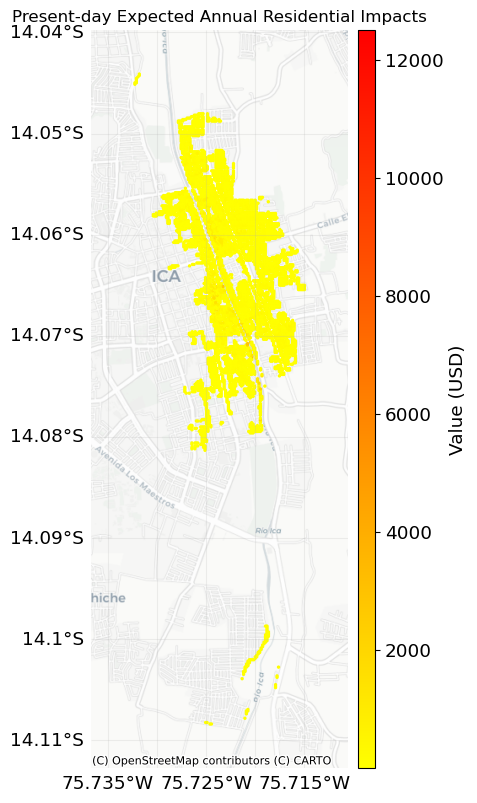

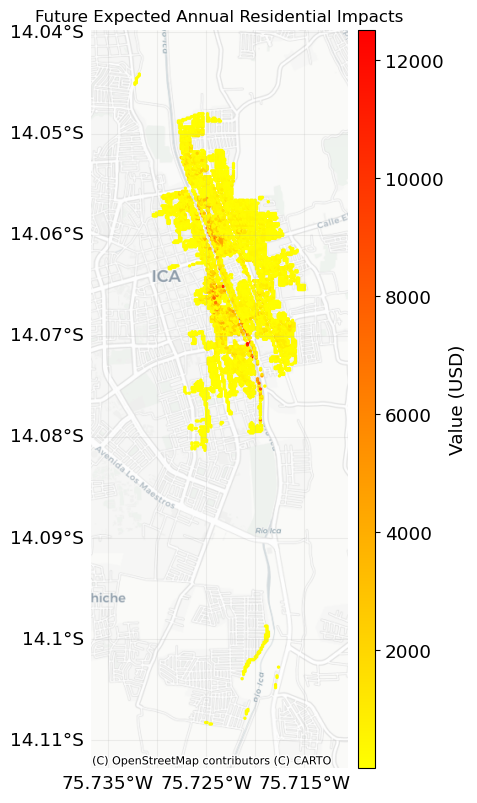

In [16]:
import contextily as ctx

# ----------------------------
# Map expected annual impacts
# ----------------------------

max_impact = impact_future.eai_exp.max()

axis = impact_present.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=2,                                # The size of point markers on the plot
    zoom=14,                            # Level of detail to add to the basemap
    cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    vmax=max_impact,                    # Set the maximum value for the colour scale
    url=ctx.providers.CartoDB.Positron, # Basemap provider
    figsize=(6, 8)
)
axis.set_title(f"Present-day Expected Annual Residential Impacts")
plt.show()
plt.close(axis.figure)

axis = impact_future.plot_basemap_eai_exposure(
    ignore_zero=True,                   # Don't plot locations with zero impacts
    pop_name=False,                     # Don't plot place names
    buffer=500,                         # Add spatial buffers to the map (in the CRS coordinate units)
    s=2,                                # The size of point markers on the plot
    zoom=14,                            # Level of detail to add to the basemap
    cmap="autumn_r",                    # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
    vmax=max_impact,                    # Set the maximum value for the colour scale
    url=ctx.providers.CartoDB.Positron, # Basemap provider
    figsize=(6, 8)
)
axis.set_title(f"Future Expected Annual Residential Impacts")
plt.show()
plt.close(axis.figure)


### Further exploration of the breakdown of risk

By running different Impact calculations, we can explore how changes to hazard and exposures drive changes in the risk calculation.

Here we show four risk calculations, each for different components of risk. (Some of these we did already but we show them again for completeness.). We can then summarize the results in a table and generate a more detailed waterfall plot.

In [17]:
# 1. Present-day exposure + present-day hazard
impact_present_present = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 2. Future exposure + present-day hazard
impact_future_exp_only = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_present
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 3. Present-day exposure + future hazard
impact_future_haz_only = ImpactCalc(
    entity_present.exposures,
    entity_present.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

# 4. Future exposure + future hazard
impact_future_combined = ImpactCalc(
    entity_future.exposures,
    entity_future.impact_funcs,
    haz_future
).impact(
    save_mat=True,
    assign_centroids=False,
    ignore_cover=True,
    ignore_deductible=True
)

decomp_df = pd.DataFrame({
    "Scenario": [
        "Present-day exposure + present-day hazard",
        "Future exposure + present-day hazard",
        "Present-day exposure + future hazard",
        "Future exposure + future hazard"
    ],
    "Average annual impact (USD)": [
        impact_present_present.aai_agg,
        impact_future_exp_only.aai_agg,
        impact_future_haz_only.aai_agg,
        impact_future_combined.aai_agg
    ]
})

decomp_df["% increase from baseline"] = (
    decomp_df["Average annual impact (USD)"]
    / decomp_df["Average annual impact (USD)"].iloc[0]
    - 1
) * 100

numeric_cols = decomp_df.select_dtypes(include="number").columns
display(
    decomp_df.style.format({
        "Average annual impact (USD)": "{:,.0f}",
        "% increase from baseline": "{:.2f}%"
    })
)


2026-07-02 15:07:15,154 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.
2026-07-02 15:07:15,220 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.
2026-07-02 15:07:15,277 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.
2026-07-02 15:07:15,331 - climada.engine.impact_calc - INFO - Calculating impact for 17955 assets (>0) and 6 events.


,Scenario,Average annual impact (USD),% increase from baseline
0,Present-day exposure + present-day hazard,"559,693",0.00%
1,Future exposure + present-day hazard,"1,122,553",100.57%
2,Present-day exposure + future hazard,"1,266,610",126.30%
3,Future exposure + future hazard,"2,540,387",353.89%


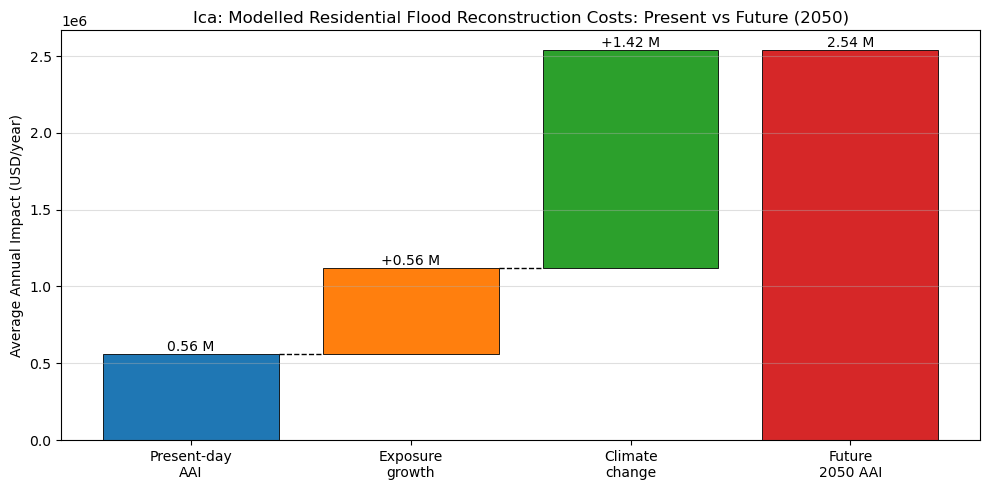

In [18]:

# ---------------------------------------
# Create a more detailed waterfall plot
# ---------------------------------------

# Gather the data we need

baseline_aai = impact_present_present.aai_agg
exp_only_aai = impact_future_exp_only.aai_agg
combined_aai = impact_future_combined.aai_agg

exposure_growth_effect = exp_only_aai - baseline_aai
climate_change_effect = combined_aai - exp_only_aai

components = [
    "Present-day\nAAI",
    "Exposure\ngrowth",
    "Climate\nchange",
    "Future\n2050 AAI"
]

heights = [
    baseline_aai,
    exposure_growth_effect,
    climate_change_effect,
    combined_aai
]

bottoms = [
    0,
    baseline_aai,
    baseline_aai + exposure_growth_effect,
    0
]

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red"
]

# Build the plot!

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    np.arange(len(components)),
    heights,
    bottom=bottoms,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

running_totals = [
    baseline_aai,
    baseline_aai + exposure_growth_effect,
    combined_aai
]

for i in range(len(running_totals) - 1):
    ax.plot(
        [i + 0.4, i + 1 - 0.4],
        [running_totals[i], running_totals[i]],
        color="black",
        linestyle="--",
        linewidth=1
    )

for i, (bottom, height) in enumerate(zip(bottoms, heights)):
    if i == 0 or i == len(components) - 1:
        label_y = height
        label_text = f"{height / 1e6:.2f} M"
    else:
        label_y = bottom + height
        label_text = f"+{height / 1e6:.2f} M"

    ax.text(
        i,
        label_y,
        label_text,
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xticks(np.arange(len(components)))
ax.set_xticklabels(components)
ax.set_ylabel("Average Annual Impact (USD/year)")
ax.set_title("Ica: Modelled Residential Flood Reconstruction Costs: Present vs Future (2050)")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

waterfall_plot_df = pd.DataFrame({
    "component": [
        "Present-day AAI",
        "Exposure growth",
        "Climate change",
        "Future 2050 AAI"
    ],
    "value_usd": heights,
    "bottom_usd": bottoms
})


### Extensions to this notebook

Note: this is a first version of the notebook. It should give you enough information to build and run your own future risk analyses.

There are still a few improvements to make to the data:
- repeat the above analysis for 'affected' and 'destroyed' housing
- use all three asset types
- use of projected socioeconomic change information to estimate future asset values
- more scientifically-grounded estimations of the changes of flood return periods under climate change
